In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for easier inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load both datasets
base_path = "/Users/junyup/Desktop/workspace/SafeTrader_Detection"

path1 = f"{base_path}/Fraudulent_E-Commerce_Transaction_Data.csv"
path2 = f"{base_path}/Fraudulent_E-Commerce_Transaction_Data_2.csv"

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

# Quick sanity check before merging: do both have the same columns?
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("Columns match:", list(df1.columns) == list(df2.columns))

df1 shape: (1472952, 16)
df2 shape: (23634, 16)
Columns match: True


In [3]:
# Combine the two datasets
# Mark the source of each row in case we need to trace it back later
df1["source_file"] = "main"
df2["source_file"] = "extra"

df = pd.concat([df1, df2], axis=0, ignore_index=True)

# Remove exact duplicate rows (e.g. same Transaction ID appearing in both files)
df = df.drop_duplicates().reset_index(drop=True)

# Basic checks after merging
print("Combined shape:", df.shape)
print()
print(df.info())
print()
print(df.head())

Combined shape: (1496586, 17)

<class 'pandas.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  str    
 1   Customer ID         1496586 non-null  str    
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  str    
 4   Payment Method      1496586 non-null  str    
 5   Product Category    1496586 non-null  str    
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  str    
 9   Device Used         1496586 non-null  str    
 10  IP Address          1496586 non-null  str    
 11  Shipping Address    1496586 non-null  str    
 12  Billing Address     1496586 non-null  str    
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  


In [4]:
# Check for missing values
# Count of missing values per column
missing_count = df.isnull().sum()

# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a single summary table, sorted by count descending
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

print(missing_summary)

# Quick check: are there any missing values at all?
print("Total missing values:", df.isnull().sum().sum())

                    missing_count  missing_percent
Transaction ID                  0              0.0
Device Used                     0              0.0
Transaction Hour                0              0.0
Account Age Days                0              0.0
Is Fraudulent                   0              0.0
Billing Address                 0              0.0
Shipping Address                0              0.0
IP Address                      0              0.0
Customer Location               0              0.0
Customer ID                     0              0.0
Customer Age                    0              0.0
Quantity                        0              0.0
Product Category                0              0.0
Payment Method                  0              0.0
Transaction Date                0              0.0
Transaction Amount              0              0.0
source_file                     0              0.0
Total missing values: 0


Is Fraudulent
0    1421526
1      75060
Name: count, dtype: int64
Is Fraudulent
0    94.984585
1     5.015415
Name: proportion, dtype: float64


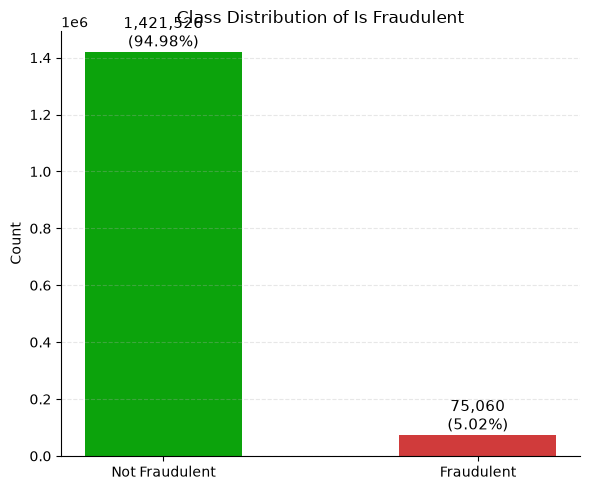

In [5]:
# Check class distribution of the target (Is Fraudulent)
target_counts = df["Is Fraudulent"].value_counts().sort_index()
target_percent = df["Is Fraudulent"].value_counts(normalize=True).sort_index() * 100

print(target_counts)
print(target_percent)

# Visualize the distribution
labels = ["Not Fraudulent", "Fraudulent"]
colors = ["#0ca30c", "#d03b3b"]  # good vs critical status colors

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, target_counts.values, color=colors, width=0.5)

# Direct labels: show count and percentage on top of each bar
for bar, count, pct in zip(bars, target_counts.values, target_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.2f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Class Distribution of Is Fraudulent")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Basic descriptive statistics

# Numeric columns: count, mean, std, min, quartiles, max
print(df.describe())

# Categorical/object columns: count, unique, top, freq
print(df.describe(include="object"))

# All columns together (numeric + categorical) for a quick overview
print(df.describe(include="all"))

# Skewness and kurtosis for numeric columns (useful for spotting outliers/asymmetry)
numeric_cols = df.select_dtypes(include=np.number).columns
print("Skewness:\n", df[numeric_cols].skew())
print("Kurtosis:\n", df[numeric_cols].kurt())

       Transaction Amount      Quantity  Customer Age  Is Fraudulent  \
count        1.496586e+06  1.496586e+06  1.496586e+06   1.496586e+06   
mean         2.268093e+02  3.000235e+00  3.451284e+01   5.015415e-02   
std          2.705831e+02  1.414814e+00  1.000323e+01   2.182630e-01   
min          1.000000e+01  1.000000e+00 -1.600000e+01   0.000000e+00   
25%          6.862000e+01  2.000000e+00  2.800000e+01   0.000000e+00   
50%          1.517600e+02  3.000000e+00  3.500000e+01   0.000000e+00   
75%          2.960500e+02  4.000000e+00  4.100000e+01   0.000000e+00   
max          1.270175e+04  5.000000e+00  8.600000e+01   1.000000e+00   

       Account Age Days  Transaction Hour  
count      1.496586e+06      1.496586e+06  
mean       1.796308e+02      1.128663e+01  
std        1.068726e+02      6.976067e+00  
min        1.000000e+00      0.000000e+00  
25%        8.600000e+01      5.000000e+00  
50%        1.790000e+02      1.100000e+01  
75%        2.720000e+02      1.700000e+01  

/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/1896459266.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


                              Transaction ID  \
count                                1496586   
unique                               1496586   
top     15d2e414-8735-46fc-9e02-80b472b2580f   
freq                                       1   

                                 Customer ID     Transaction Date  \
count                                1496586              1496586   
unique                               1496586              1366540   
top     d1b87f62-51b2-493b-ad6a-77e0fe13e785  2024-01-27 04:00:16   
freq                                       1                    6   

       Payment Method Product Category Customer Location Device Used  \
count         1496586          1496586           1496586     1496586   
unique              4                5             99412           3   
top       credit card      electronics       New Michael      mobile   
freq           374352           300042              1276      499624   

            IP Address            Shipping Address  

/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/410641100.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


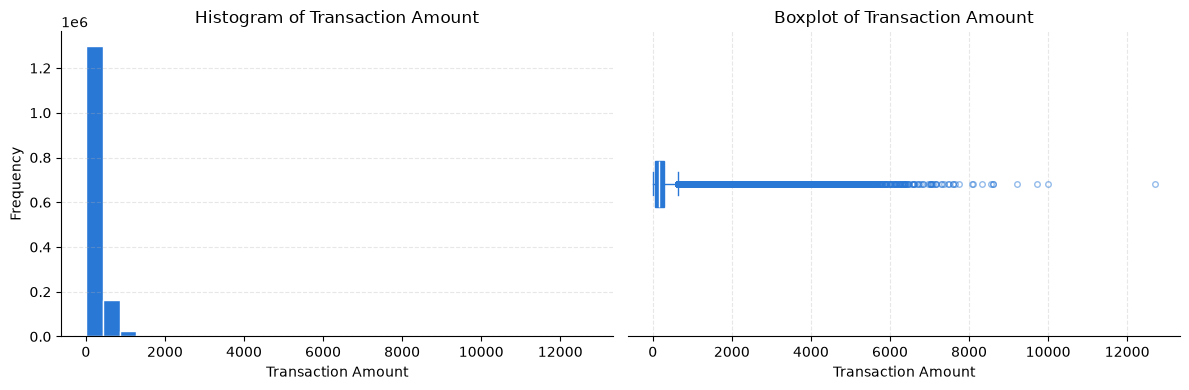

/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/410641100.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


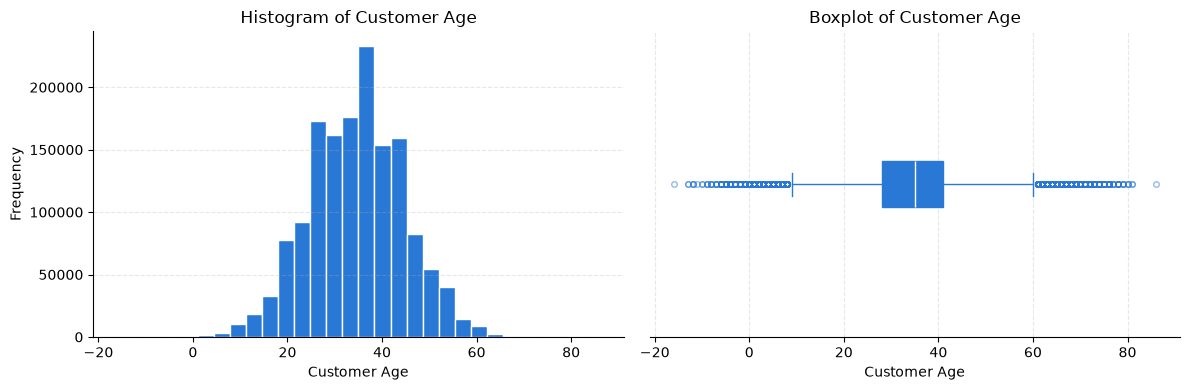

/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/410641100.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


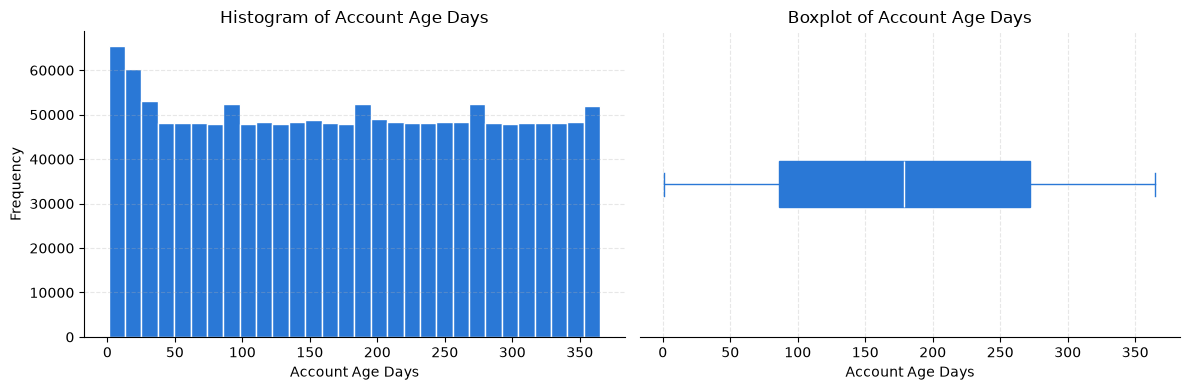

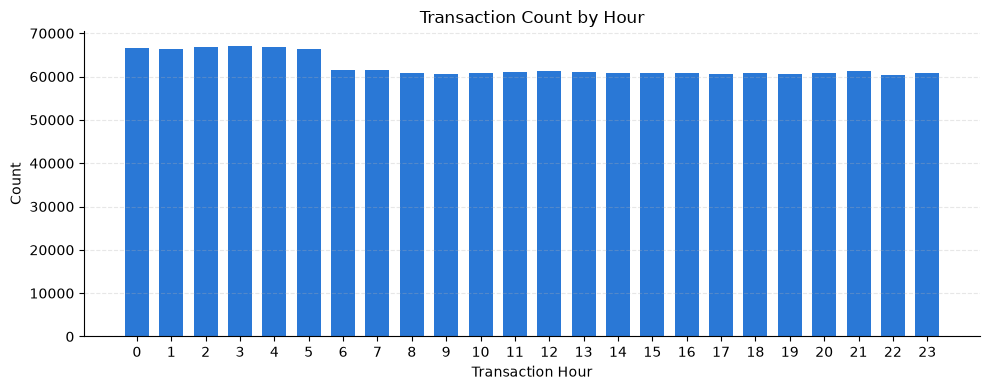

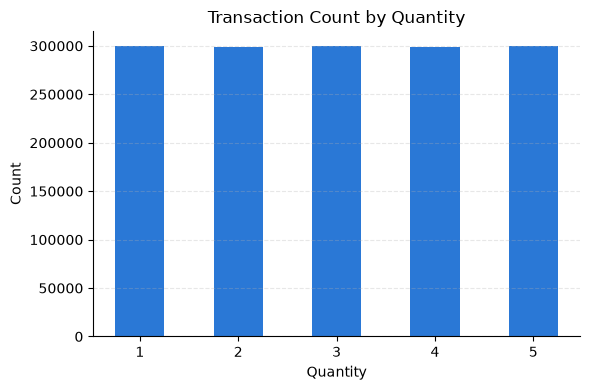

In [7]:
# Distribution of numeric variables: histogram + boxplot
# Transaction Hour and Quantity are excluded here since they are discrete/ordinal variables, not continuous
numeric_cols = ["Transaction Amount", "Customer Age", "Account Age Days"]

color = "#2a78d6"  # single sequential hue for magnitude/distribution

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(df[col].dropna(), bins=30, color=color, edgecolor="white")
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].spines[["top", "right"]].set_visible(False)
    axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    # Boxplot
    axes[1].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, color=color),
        medianprops=dict(color="white"),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(markeredgecolor=color, markersize=4, alpha=0.5),
    )
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_yticks([])
    axes[1].spines[["top", "right", "left"]].set_visible(False)
    axes[1].grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Transaction Hour: treated as a categorical/ordinal variable
hour_counts = df["Transaction Hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hour_counts.index, hour_counts.values, color=color, width=0.7)

ax.set_title("Transaction Count by Hour")
ax.set_xlabel("Transaction Hour")
ax.set_ylabel("Count")
ax.set_xticks(range(0, 24))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Quantity: treated as a categorical/ordinal variable (1-5)
qty_counts = df["Quantity"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(qty_counts.index, qty_counts.values, color=color, width=0.5)

ax.set_title("Transaction Count by Quantity")
ax.set_xlabel("Quantity")
ax.set_ylabel("Count")
ax.set_xticks(qty_counts.index)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Q1: 68.62, Q3: 296.05, IQR: 227.43
Lower bound: -272.525, Upper bound: 637.1949999999999
Number of outliers: 80519 (5.38%)

--- Outlier group stats ---
count    80519.000000
mean      1004.111660
std        586.041088
min        637.200000
25%        706.930000
50%        814.600000
75%       1033.925000
max      12701.750000
Name: Transaction Amount, dtype: float64

--- Non-outlier group stats ---
count    1.416067e+06
mean     1.826112e+02
std      1.467688e+02
min      1.000000e+01
25%      6.501000e+01
50%      1.411300e+02
75%      2.644400e+02
max      6.371900e+02
Name: Transaction Amount, dtype: float64

--- Top 20 largest transactions ---
                               Transaction ID  Transaction Amount  \
844823   a7c9414c-647c-457a-97f5-aa875bb39093            12701.75   
551224   2ad1bb33-473a-4881-b14d-8471991114cb             9990.90   
1486692  6e97ba1f-2013-4c6e-a57c-d868c20ef291             9716.50   
731174   091061e5-646f-4f55-b978-8fdfa1375eb9             9221.60   

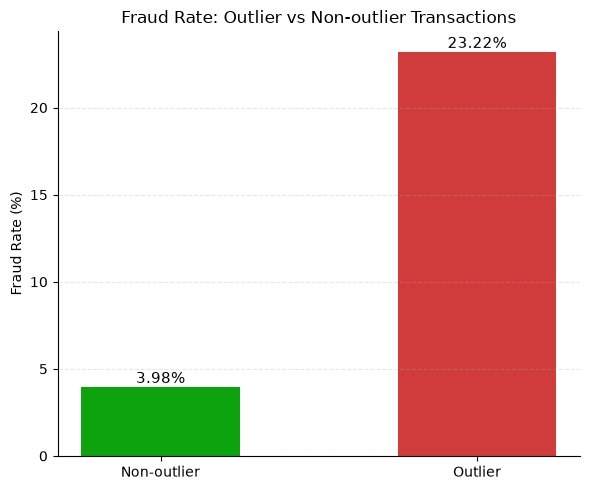


--- Outlier distribution by Payment Method ---
Payment Method
debit card       20262
credit card      20204
bank transfer    20122
PayPal           19931
Name: count, dtype: int64

--- Outlier distribution by Product Category ---
Product Category
health & beauty    16213
electronics        16151
home & garden      16141
clothing           16012
toys & games       16002
Name: count, dtype: int64

--- Outlier distribution by Device Used ---
Device Used
mobile     27152
tablet     26802
desktop    26565
Name: count, dtype: int64


In [8]:
# Deep dive into Transaction Amount outliers

# IQR-based outlier detection
Q1 = df["Transaction Amount"].quantile(0.25)
Q3 = df["Transaction Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers = df[(df["Transaction Amount"] < lower_bound) | (df["Transaction Amount"] > upper_bound)]
non_outliers = df[(df["Transaction Amount"] >= lower_bound) & (df["Transaction Amount"] <= upper_bound)]

print(f"Number of outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}%)")

# ===== Compare descriptive stats: outliers vs non-outliers =====
print("\n--- Outlier group stats ---")
print(outliers["Transaction Amount"].describe())

print("\n--- Non-outlier group stats ---")
print(non_outliers["Transaction Amount"].describe())

# Top 20 largest transactions
print("\n--- Top 20 largest transactions ---")
print(df.nlargest(20, "Transaction Amount")[
    ["Transaction ID", "Transaction Amount", "Payment Method", "Product Category", "Is Fraudulent"]
])

# Fraud rate: outliers vs non-outliers
fraud_rate_outliers = outliers["Is Fraudulent"].mean() * 100
fraud_rate_non_outliers = non_outliers["Is Fraudulent"].mean() * 100

print(f"\nFraud rate in outliers: {fraud_rate_outliers:.2f}%")
print(f"Fraud rate in non-outliers: {fraud_rate_non_outliers:.2f}%")

# Visualize: fraud rate comparison between outlier groups
groups = ["Non-outlier", "Outlier"]
fraud_rates = [fraud_rate_non_outliers, fraud_rate_outliers]
colors = ["#0ca30c", "#d03b3b"]  # good vs critical status colors

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(groups, fraud_rates, color=colors, width=0.5)

for bar, rate in zip(bars, fraud_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=11)

ax.set_title("Fraud Rate: Outlier vs Non-outlier Transactions")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Breakdown of outliers by categorical variables
for col in ["Payment Method", "Product Category", "Device Used"]:
    print(f"\n--- Outlier distribution by {col} ---")
    print(outliers[col].value_counts())

Date range: 2024-01-01 00:00:00 ~ 2024-04-07 08:54:03


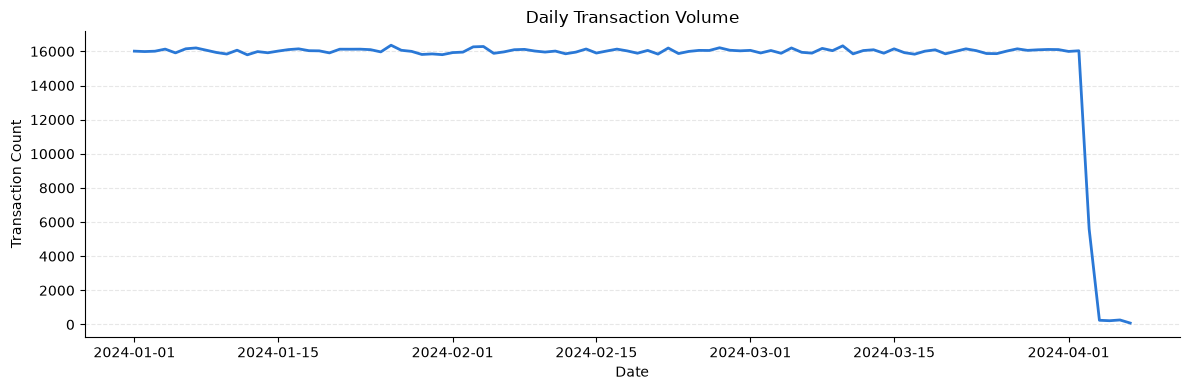

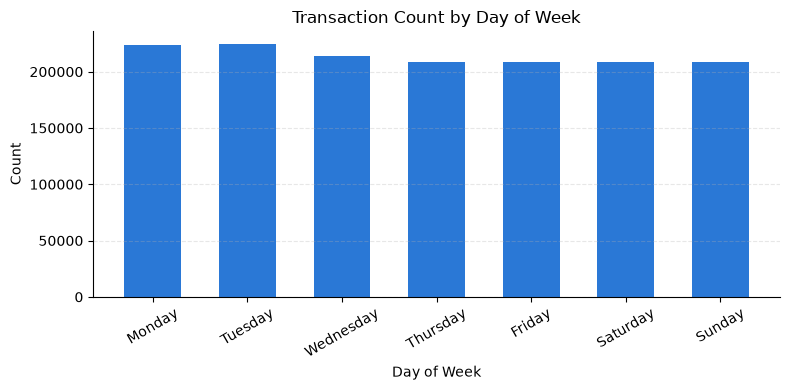

In [9]:
# Convert Transaction Date to datetime and extract time features
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# Check the date range
print("Date range:", df["Transaction Date"].min(), "~", df["Transaction Date"].max())

# Extract useful time-based features
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["Day"] = df["Transaction Date"].dt.day
df["DayOfWeek"] = df["Transaction Date"].dt.day_name()
df["Date"] = df["Transaction Date"].dt.date

# ===== Visualize transaction volume over time (daily) =====
daily_counts = df.groupby("Date").size()

color = "#2a78d6"  # single sequential hue, consistent with earlier charts

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_counts.index, daily_counts.values, color=color, linewidth=2)

ax.set_title("Daily Transaction Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Transaction Count")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Transaction count by day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["DayOfWeek"].value_counts().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weekday_counts.index, weekday_counts.values, color=color, width=0.6)

ax.set_title("Transaction Count by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


--- Device Used ---
Unique values: 3
Device Used
mobile     499624
tablet     498768
desktop    498194
Name: count, dtype: int64

--- Product Category ---
Unique values: 5
Product Category
electronics        300042
health & beauty    300038
clothing           299018
toys & games       298996
home & garden      298492
Name: count, dtype: int64

--- Payment Method ---
Unique values: 4
Payment Method
credit card      374352
debit card       374229
bank transfer    374138
PayPal           373867
Name: count, dtype: int64


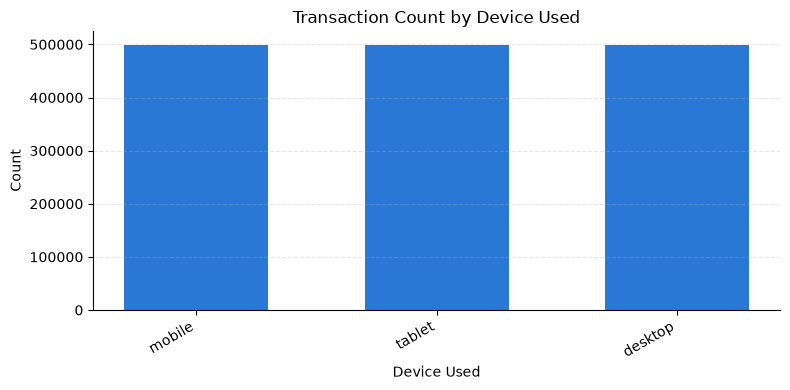

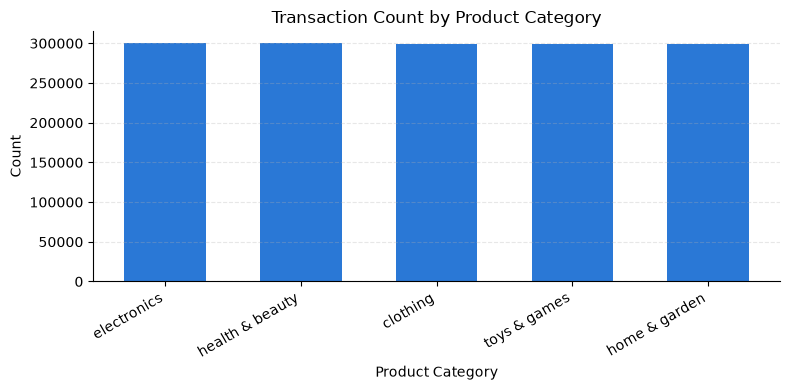

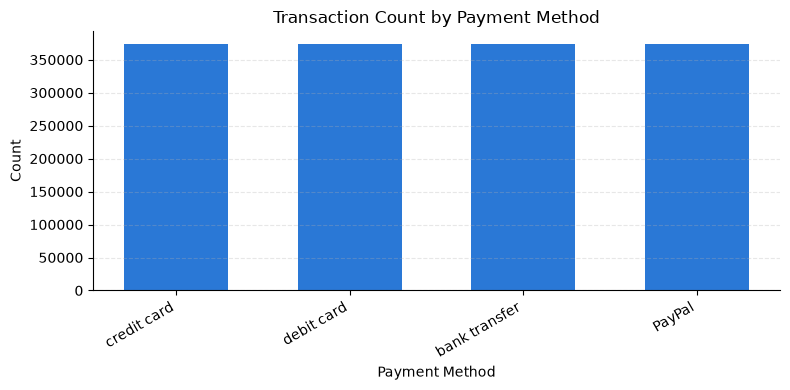

In [10]:
# Explore categorical variables: unique values and counts
categorical_cols = ["Device Used", "Product Category", "Payment Method"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts())

# Visualize counts for each categorical variable
color = "#2a78d6"  # single sequential hue, consistent with earlier charts

for col in categorical_cols:
    counts = df[col].value_counts().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(counts.index, counts.values, color=color, width=0.6)

    ax.set_title(f"Transaction Count by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()


--- Transaction Amount grouped by Is Fraudulent ---
                   count        mean         std   min     25%      50%  \
Is Fraudulent                                                             
0              1421526.0  209.846942  199.930360  10.0   67.35  148.510   
1                75060.0  548.052389  770.812069  10.0  106.30  256.075   

                    75%       max  
Is Fraudulent                      
0              287.1000   3570.78  
1              634.7775  12701.75  


/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/1959083254.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


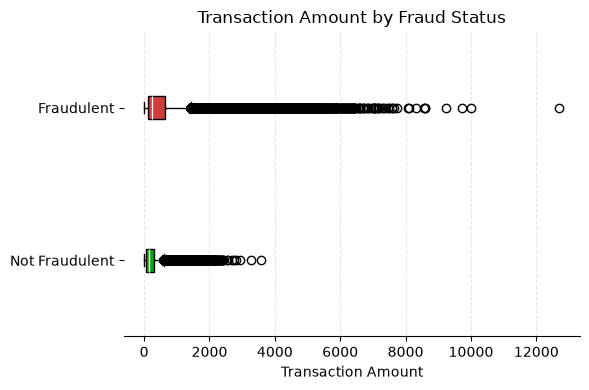


--- Customer Age grouped by Is Fraudulent ---
                   count       mean        std   min   25%   50%   75%   max
Is Fraudulent                                                               
0              1421526.0  34.515217  10.002786 -16.0  28.0  35.0  41.0  86.0
1                75060.0  34.467852  10.011661 -12.0  28.0  34.0  41.0  79.0


/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/1959083254.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


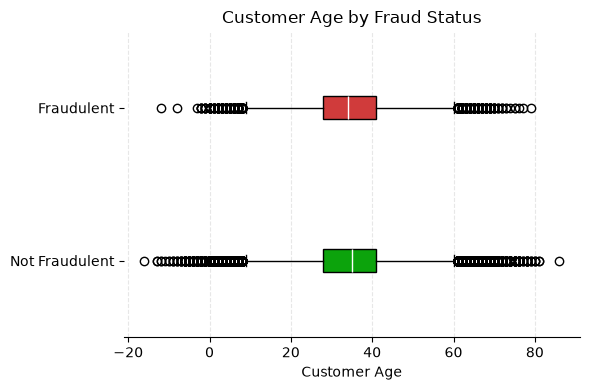


--- Account Age Days grouped by Is Fraudulent ---
                   count        mean         std  min   25%    50%    75%  \
Is Fraudulent                                                               
0              1421526.0  182.977823  105.309238  1.0  92.0  183.0  274.0   
1                75060.0  116.243685  116.077137  1.0  17.0   61.0  214.0   

                 max  
Is Fraudulent         
0              365.0  
1              365.0  


/var/folders/0s/09z64pb17zzbjc8jy9_jttr80000gn/T/ipykernel_1628/1959083254.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


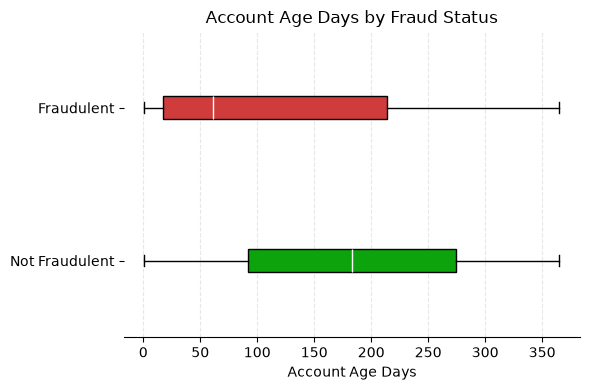

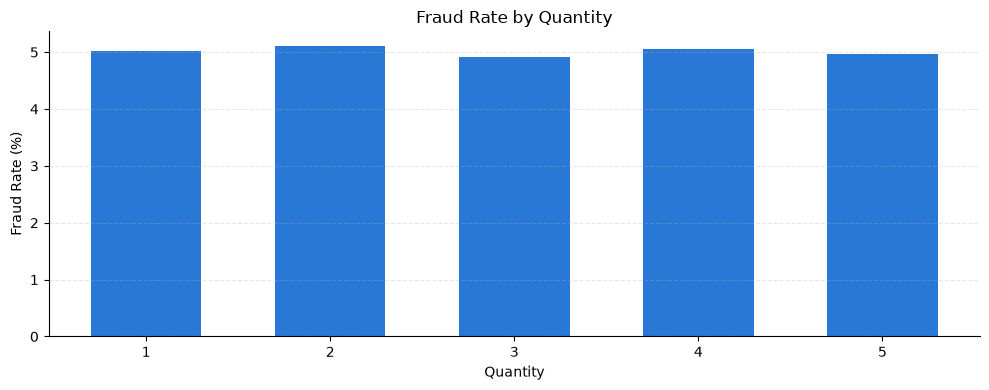

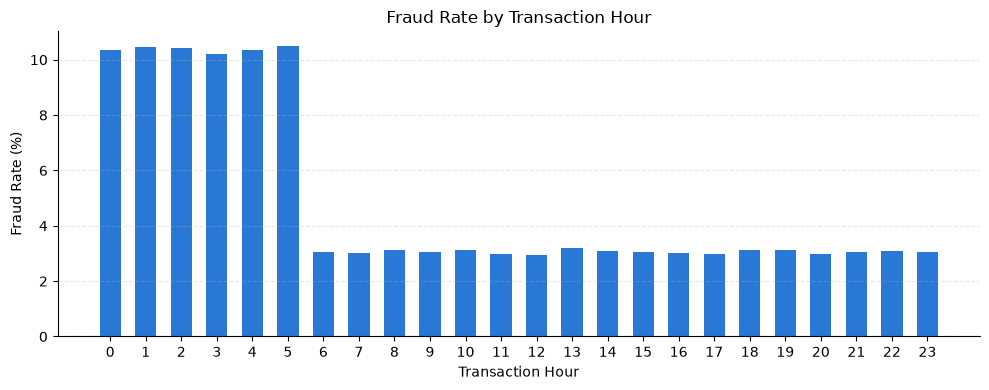


--- Fraud rate by Payment Method ---
Payment Method
bank transfer    5.047870
PayPal           5.025049
debit card       5.016447
credit card      4.972326
Name: Is Fraudulent, dtype: float64


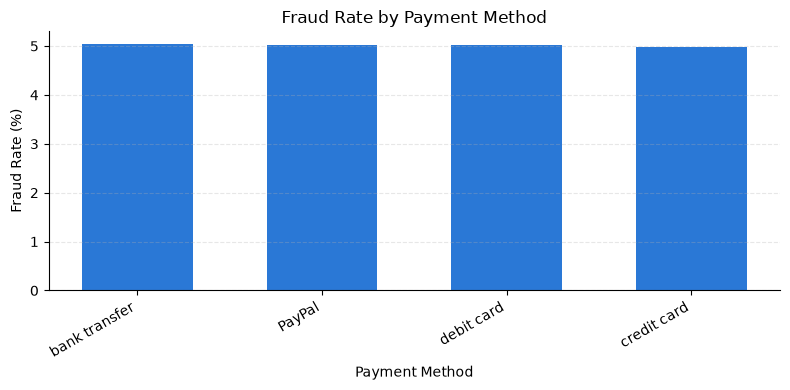


--- Fraud rate by Product Category ---
Product Category
toys & games       5.045218
clothing           5.040165
health & beauty    5.021031
home & garden      5.019900
electronics        4.950974
Name: Is Fraudulent, dtype: float64


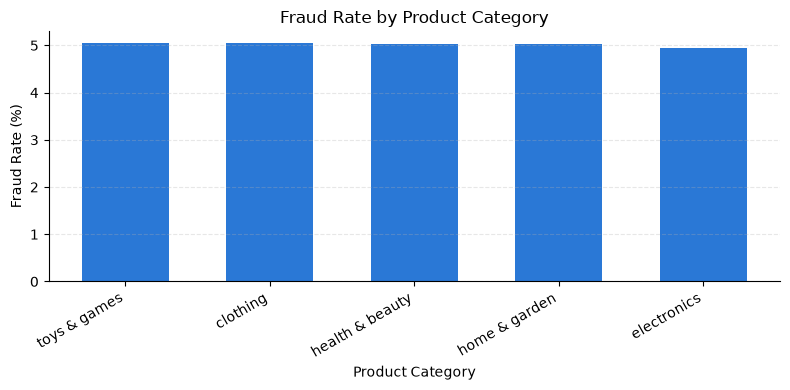


--- Fraud rate by Device Used ---
Device Used
mobile     5.063007
tablet     4.994506
desktop    4.988619
Name: Is Fraudulent, dtype: float64


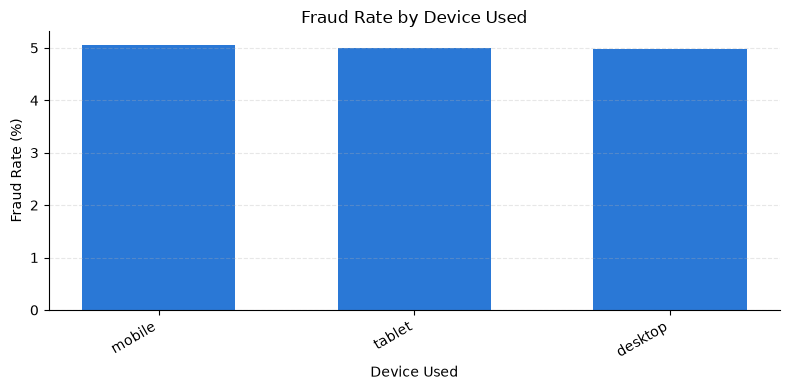

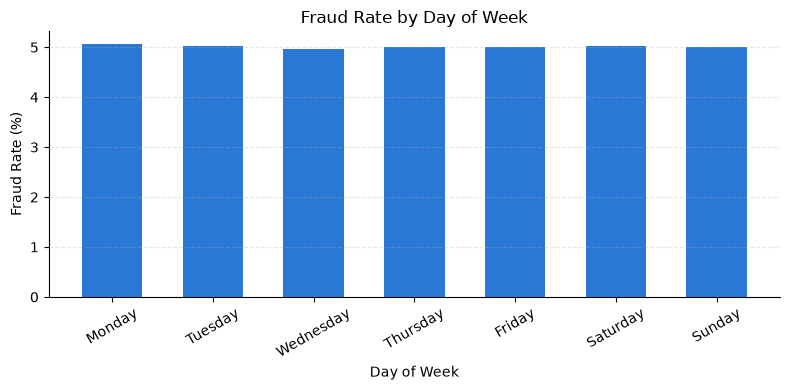

In [11]:
# Split analysis by Is Fraudulent (0 = Not Fraudulent, 1 = Fraudulent)

status_colors = {0: "#0ca30c", 1: "#d03b3b"}  # good vs critical
status_labels = {0: "Not Fraudulent", 1: "Fraudulent"}

# Numeric variables: describe + boxplot grouped by fraud status
numeric_cols = ["Transaction Amount", "Customer Age", "Account Age Days"]

for col in numeric_cols:
    print(f"\n--- {col} grouped by Is Fraudulent ---")
    print(df.groupby("Is Fraudulent")[col].describe())

    fig, ax = plt.subplots(figsize=(6, 4))
    data_to_plot = [df[df["Is Fraudulent"] == 0][col].dropna(),
                     df[df["Is Fraudulent"] == 1][col].dropna()]

    bp = ax.boxplot(
        data_to_plot,
        vert=False,
        patch_artist=True,
        medianprops=dict(color="white"),
    )
    ax.set_yticks([1, 2])
    ax.set_yticklabels([status_labels[0], status_labels[1]])

    for patch, key in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(status_colors[key])

    ax.set_title(f"{col} by Fraud Status")
    ax.set_xlabel(col)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


# Discrete/ordinal variables: fraud rate by value
discrete_cols = ["Quantity", "Transaction Hour"]

for col in discrete_cols:
    fraud_rate = df.groupby(col)["Is Fraudulent"].mean().sort_index() * 100

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(fraud_rate.index, fraud_rate.values, color="#2a78d6", width=0.6)

    ax.set_title(f"Fraud Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_xticks(fraud_rate.index)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Categorical variables: fraud rate by category
categorical_cols = ["Payment Method", "Product Category", "Device Used"]

for col in categorical_cols:
    fraud_rate = df.groupby(col)["Is Fraudulent"].mean().sort_values(ascending=False) * 100

    print(f"\n--- Fraud rate by {col} ---")
    print(fraud_rate)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(fraud_rate.index, fraud_rate.values, color="#2a78d6", width=0.6)

    ax.set_title(f"Fraud Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud Rate (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

# Time-based fraud rate: day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_rate_weekday = df.groupby("DayOfWeek")["Is Fraudulent"].mean().reindex(weekday_order) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fraud_rate_weekday.index, fraud_rate_weekday.values, color="#2a78d6", width=0.6)

ax.set_title("Fraud Rate by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

--- Address Match Counts ---
Address_Match
True     1346721
False     149865
Name: count, dtype: int64

--- Address Match Percentage ---
Address_Match
True     89.986209
False    10.013791
Name: proportion, dtype: float64

--- Fraud Rate by Address Match ---
Address_Match
False    4.989824
True     5.018263
Name: Is Fraudulent, dtype: float64


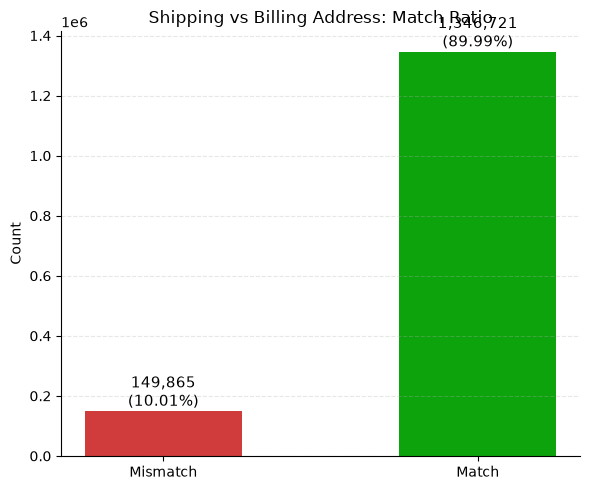

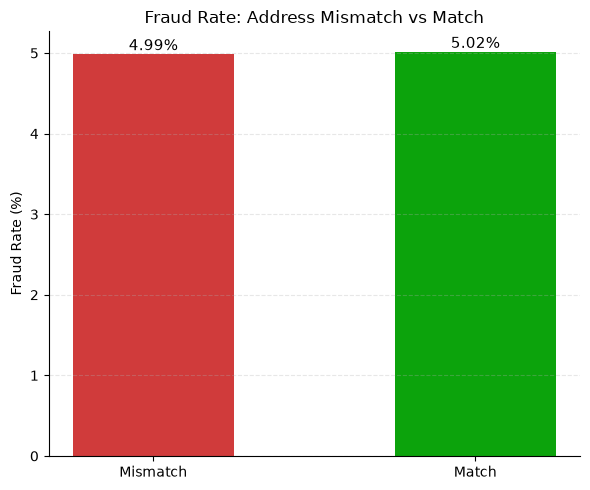

In [12]:
# Shipping Address vs Billing Address mismatch analysis

# Create a flag: True if shipping and billing addresses match
df["Address_Match"] = df["Shipping Address"] == df["Billing Address"]

# Proportion of match vs mismatch
match_counts = df["Address_Match"].value_counts()
match_percent = df["Address_Match"].value_counts(normalize=True) * 100

print("--- Address Match Counts ---")
print(match_counts)
print("\n--- Address Match Percentage ---")
print(match_percent)

# Fraud rate by address match status
fraud_rate_by_match = df.groupby("Address_Match")["Is Fraudulent"].mean() * 100
print("\n--- Fraud Rate by Address Match ---")
print(fraud_rate_by_match)

# Visualize: proportion of match vs mismatch
labels = ["Mismatch", "Match"]
colors = ["#d03b3b", "#0ca30c"]  # critical vs good

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, [match_counts.get(False, 0), match_counts.get(True, 0)], color=colors, width=0.5)

for bar, count in zip(bars, [match_counts.get(False, 0), match_counts.get(True, 0)]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}\n({pct:.2f}%)", ha="center", va="bottom", fontsize=11)

ax.set_title("Shipping vs Billing Address: Match Ratio")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize: fraud rate by address match status
fraud_rate_values = [fraud_rate_by_match.get(False, 0), fraud_rate_by_match.get(True, 0)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, fraud_rate_values, color=colors, width=0.5)

for bar, rate in zip(bars, fraud_rate_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{rate:.2f}%", ha="center", va="bottom", fontsize=11)

ax.set_title("Fraud Rate: Address Mismatch vs Match")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

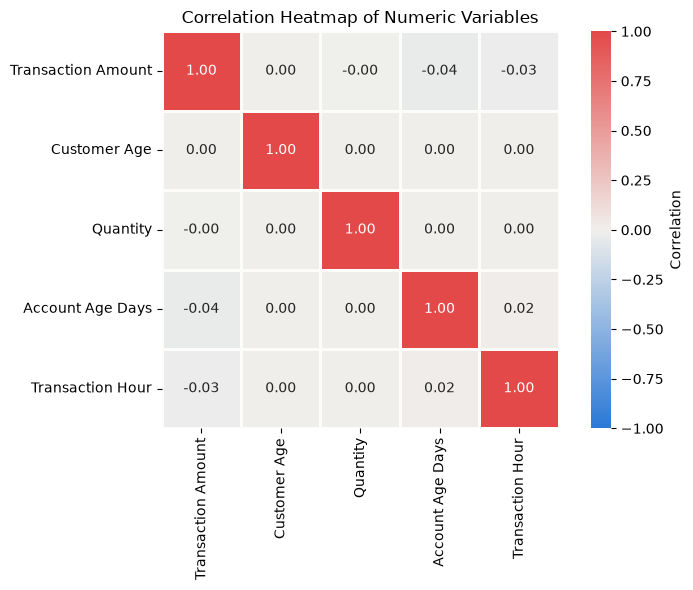

In [13]:
# Correlation heatmap of numeric variables
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = ["Transaction Amount", "Customer Age", "Quantity", "Account Age Days",
                 "Transaction Hour"]

corr = df[numeric_cols].corr()

# Diverging colormap: blue (negative) - gray (zero) - red (positive)
diverging_cmap = LinearSegmentedColormap.from_list(
    "diverging", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=diverging_cmap,
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=1, linecolor="#fcfcfb",
    cbar_kws={"label": "Correlation"},
    ax=ax,
)

ax.set_title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [14]:
# Customer Location: cardinality check (too high to plot directly like other categoricals)
print("Unique Customer Location values:", df["Customer Location"].nunique())
print("Total rows:", len(df))
print("Locations appearing only once:", (df["Customer Location"].value_counts() == 1).sum())

print("\n--- Top 20 most frequent locations ---")
print(df["Customer Location"].value_counts().head(20))

Unique Customer Location values: 99412
Total rows: 1496586
Locations appearing only once: 18716

--- Top 20 most frequent locations ---
Customer Location
New Michael       1276
East Michael      1230
South Michael     1226
Port Michael      1219
Lake Michael      1218
West Michael      1216
North Michael     1192
Michaelmouth       900
West David         881
New David          870
Smithmouth         868
West Jennifer      863
North David        857
East David         843
Port David         834
East John          830
West James         828
Lake James         828
Lake Jennifer      826
North Jennifer     821
Name: count, dtype: int64


                   fraud_rate  count
Customer Location                   
Lake Jennifer        6.900726    826
Lake James           6.884058    828
West Jennifer        6.257242    863
East Michael         5.934959   1230
Smithmouth           5.760369    868
Port David           5.755396    834
Port Michael         5.496308   1219
West Michael         5.345395   1216
West James           5.314010    828
East John            5.301205    830
Michaelmouth         5.222222    900
East David           5.219454    843
North David          5.134189    857
New David            4.712644    870
North Michael        4.697987   1192
Lake Michael         4.597701   1218
West David           4.540295    881
New Michael          4.388715   1276
South Michael        4.078303   1226
North Jennifer       3.166870    821


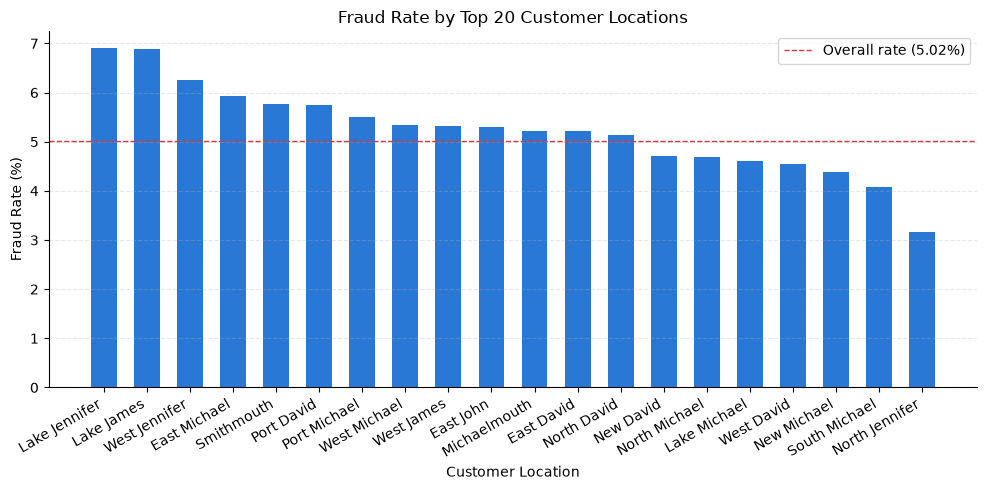

In [15]:
# Fraud rate for the top-N most frequent locations
# (rare locations are excluded here since a single transaction gives an unreliable rate)
top_n = 20
top_locations = df["Customer Location"].value_counts().head(top_n).index

fraud_by_location = (
    df[df["Customer Location"].isin(top_locations)]
    .groupby("Customer Location")["Is Fraudulent"]
    .agg(fraud_rate="mean", count="size")
)
fraud_by_location["fraud_rate"] *= 100
fraud_by_location = fraud_by_location.sort_values("fraud_rate", ascending=False)

print(fraud_by_location)

color = "#2a78d6"

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(fraud_by_location.index, fraud_by_location["fraud_rate"], color=color, width=0.6)

overall_rate = df["Is Fraudulent"].mean() * 100
ax.axhline(overall_rate, color="#d03b3b", linestyle="--", linewidth=1, label=f"Overall rate ({overall_rate:.2f}%)")

ax.set_title(f"Fraud Rate by Top {top_n} Customer Locations")
ax.set_xlabel("Customer Location")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [16]:
# IP Address: check how often the same IP is reused across transactions
ip_counts = df["IP Address"].value_counts()
reused_ips = ip_counts[ip_counts > 1]

print("Unique IP addresses:", df["IP Address"].nunique())
print("Total rows:", len(df))
print(f"IPs reused (appear > 1 time): {len(reused_ips)} (covering {reused_ips.sum()} rows)")

print("\n--- Distribution of transaction count per IP ---")
print(ip_counts.value_counts().sort_index())

Unique IP addresses: 1496278
Total rows: 1496586
IPs reused (appear > 1 time): 308 (covering 616 rows)

--- Distribution of transaction count per IP ---
count
1    1495970
2        308
Name: count, dtype: int64


--- Row Counts ---
ip_reused
False    1495970
True         616
Name: count, dtype: int64

--- Fraud Rate by IP Reuse ---
ip_reused
False    5.015408
True     5.032468
Name: Is Fraudulent, dtype: float64


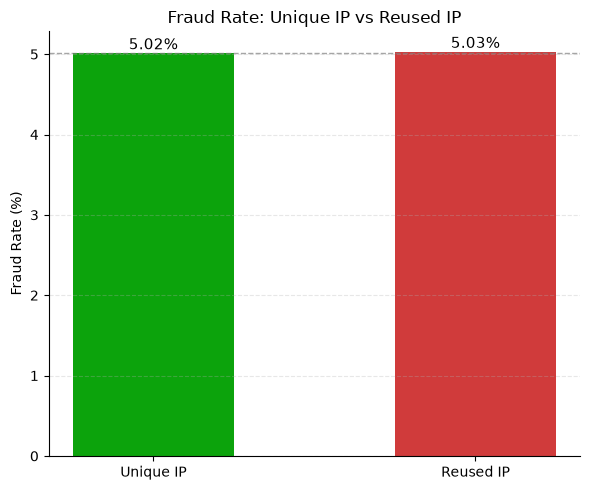

In [17]:
# Flag rows whose IP is shared with at least one other transaction
df["ip_reused"] = df["IP Address"].isin(reused_ips.index)

match_counts = df["ip_reused"].value_counts()
fraud_rate_by_ip = df.groupby("ip_reused")["Is Fraudulent"].mean() * 100

print("--- Row Counts ---")
print(match_counts)
print("\n--- Fraud Rate by IP Reuse ---")
print(fraud_rate_by_ip)

labels = ["Unique IP", "Reused IP"]
colors = ["#0ca30c", "#d03b3b"]  # good vs critical
fraud_rate_values = [fraud_rate_by_ip.get(False, 0), fraud_rate_by_ip.get(True, 0)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, fraud_rate_values, color=colors, width=0.5)

for bar, rate in zip(bars, fraud_rate_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{rate:.2f}%", ha="center", va="bottom", fontsize=11)

ax.axhline(df["Is Fraudulent"].mean() * 100, color="gray", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Fraud Rate: Unique IP vs Reused IP")
ax.set_ylabel("Fraud Rate (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()